# Experiments with XGBoost model

## Imports and Environment Setup

In [1]:
import os
import time
import random
import gc

import numpy as np
import pandas as pd
import tensorflow as tf
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_sample_weight

import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE

# To suppress TF Warnings:
os.environ['TF_CPP_MIN_LOG_LEVEL']= '2'

2026-07-07 11:25:21.297473: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-07 11:25:23.248040: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-07 11:25:26.185600: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/shail/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/export/tf2onnx_li

## Dataset Loading (TFRecords)

In [2]:
# Project Root Folder:
PROJECT_ROOT= os.path.dirname(os.getcwd())
print(PROJECT_ROOT)

# DataSet Path:
DATASET_PATH= 'data/processed/features.tfrecord'
print(DATASET_PATH)

# TFRecords Path:
TFRECORD_PATH= os.path.join(PROJECT_ROOT, DATASET_PATH)
print(TFRECORD_PATH)

/home/shail/disaster_triage_pipeline
data/processed/features.tfrecord
/home/shail/disaster_triage_pipeline/data/processed/features.tfrecord


In [3]:
# Fuction to Parse a Single tf.train.Example element:
def parse_tfr_element(element):
    """
    Parses a single tf.train.Example protocol buffer.
    """
    data= {
        'building_id': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.string),
        'feature_vector': tf.io.FixedLenFeature([2048], tf.float32)
    }

    content= tf.io.parse_single_example(element, data)
    return content['feature_vector'], content['label'], content['building_id']

In [4]:

# Function to Load TFRecords Dataset and Convert it into Numpy Arrays:
def load_dataset(filepath):
    """
    Loads the TFRecord dataset and converts it to numpy arrays.
    """
    print('Unpacking TFRecords Dataset...')
    dataset= tf.data.TFRecordDataset(filenames= filepath)
    dataset= dataset.map(parse_tfr_element)

    X_list, y_list, id_list= [], [], []

    for features, label, b_id in dataset:
        X_list.append(features.numpy())
        y_list.append(label.numpy().decode('utf-8'))
        id_list.append(b_id.numpy().decode('utf-8'))
    
    X= np.array(X_list)
    y= np.array(y_list)
    ids= np.array(id_list)

    print(f'Successfully Loaded {X.shape[0]} Records.')
    print(f'Feature Matrix Shape: {X.shape}')

    return X, y, ids

In [5]:
# Loding TFRecords Dataset into Numpy Array:
X_raw, y_raw, building_ids= load_dataset(filepath= TFRECORD_PATH)

Unpacking TFRecords Dataset...


I0000 00:00:1783423532.870372    1459 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9507 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
2026-07-07 11:25:33.350008: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-07-07 11:26:06.967004: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Successfully Loaded 162787 Records.
Feature Matrix Shape: (162787, 2048)


## Data Pre-Processing

In [6]:
X_raw

array([[0.03903551, 0.14880732, 0.13893297, ..., 0.7189002 , 0.16941108,
        0.111853  ],
       [0.24977316, 0.08506289, 0.0210791 , ..., 0.01439446, 0.37462792,
        0.02411834],
       [0.7700253 , 0.02744852, 0.02121252, ..., 3.1549957 , 2.186299  ,
        0.26314795],
       ...,
       [0.06229302, 0.22243787, 0.50739115, ..., 2.6689954 , 0.        ,
        0.45200884],
       [1.7906704 , 0.3464069 , 2.6978881 , ..., 0.9125542 , 1.1435668 ,
        0.37083945],
       [0.09338678, 0.15506984, 0.2102629 , ..., 1.2329613 , 0.18746613,
        0.8535187 ]], shape=(162787, 2048), dtype=float32)

In [7]:
y_raw

array(['major-damage', 'major-damage', 'major-damage', ...,
       'major-damage', 'no-damage', 'major-damage'],
      shape=(162787,), dtype='<U13')

In [8]:
building_ids

array(['hurricane-florence_00000498_post_disaster_77d3d070-19ef-4215-96a3-dd8f3fb48e84',
       'hurricane-florence_00000498_post_disaster_f4652399-5b96-47b8-9e92-d1935be0b7d2',
       'hurricane-florence_00000498_post_disaster_07b58613-5bdc-4226-ad0a-792ce1ff7820',
       ...,
       'hurricane-harvey_00000228_post_disaster_8be21bb3-a2b1-4f80-ad55-e68c4eae1212',
       'hurricane-harvey_00000228_post_disaster_80f2724e-45a1-4557-968c-88a14515356d',
       'hurricane-harvey_00000228_post_disaster_5f6aa2de-3833-4db1-aed3-b5d18fdfa370'],
      shape=(162787,), dtype='<U79')

In [9]:
np.unique(y_raw, return_counts= True)

(array(['destroyed', 'major-damage', 'minor-damage', 'no-damage',
        'un-classified'], dtype='<U13'),
 array([ 13227,  14161,  14980, 117426,   2993]))

### Label Encoding

In [10]:
# Label Encoding:
class_mapping= {
    'no-damage': 0,
    'minor-damage': 1,
    'major-damage': 2,
    'destroyed': 3,
    'un-classified': 0 # Rolling Un-Classified into no-damage for Baseline Model 
}

# Encoding Labels:
y_encoded= np.array([class_mapping.get(label, 0) for label in y_raw])

print(y_encoded)

[2 2 2 ... 2 0 2]


In [11]:
# Class Distribution:
unique, counts= np.unique(y_encoded, return_counts= True)
print('Class Distributtion:')
for u, c in zip(unique, counts):
    print(f'Class {u}: {c} Instances')

Class Distributtion:
Class 0: 120419 Instances
Class 1: 14980 Instances
Class 2: 14161 Instances
Class 3: 13227 Instances


### Train Test Split

In [12]:
X_train, X_test, y_train, y_test= train_test_split(X_raw,
                                                   y_encoded,
                                                   test_size= 0.2,
                                                   random_state= 42,
                                                   stratify= y_encoded)

print(f'Training Set Size: {X_train.shape[0]}')
print(f'Testing Set Size: {X_test.shape[0]}')

Training Set Size: 130229
Testing Set Size: 32558


## Experiment 1: Baseline XGBoost Model

### Baseline Model Training

In [13]:
print('Training Baseline XGBoost Model...')

# Initializing XGBoost Classifier:
basline_model= xgb.XGBClassifier(
    objective= 'multi:softprob', # objective 'multi:softprob' outputs probabilities for all classes, not just a single prediction
    num_class= 4,
    tree_method= 'hist',
    device= 'cuda',
    random_state= 42,
    n_jobs= -1
)

# Model Training:
basline_model.fit(X_train, y_train)
print('Training Complete.')

Training Baseline XGBoost Model...
Training Complete.


### Basline Model Evaluation

In [14]:
# Predictions on Test Set (Probabilities):
y_pred_probs= basline_model.predict_proba(X_test)
y_pred_probs

/home/shail/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [11:26:34] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


array([[7.23486364e-01, 1.60553604e-01, 3.74831855e-02, 7.84768388e-02],
       [1.83894113e-03, 2.14631888e-04, 2.44547380e-04, 9.97701943e-01],
       [8.36616337e-01, 1.10318564e-01, 2.55734548e-02, 2.74916179e-02],
       ...,
       [9.75794971e-01, 1.48431966e-02, 9.06259380e-03, 2.99210369e-04],
       [9.83404100e-01, 5.44478139e-03, 7.68760126e-03, 3.46351066e-03],
       [9.85175610e-01, 5.39576914e-03, 9.18290298e-03, 2.45655247e-04]],
      shape=(32558, 4), dtype=float32)

In [15]:
# Predictions on Test Set (Classes):
y_pred_classes= np.argmax(y_pred_probs, axis= 1)
y_pred_classes

array([0, 3, 0, ..., 0, 0, 0], shape=(32558,))

In [16]:
# Evaluating The Model:
target_names= ['No Damage (0)',
               'Minor Damage(1)',
               'Major Damage (2)',
               'Destoryed (3)']

print('--- Classification Report for Baseline XGBoost Classifier: ---')
print(classification_report(y_true= y_test,
                            y_pred= y_pred_classes,
                            target_names= target_names,
                            zero_division= 0))

--- Classification Report for Baseline XGBoost Classifier: ---
                  precision    recall  f1-score   support

   No Damage (0)       0.83      0.97      0.89     24084
 Minor Damage(1)       0.53      0.24      0.33      2996
Major Damage (2)       0.55      0.23      0.32      2832
   Destoryed (3)       0.80      0.55      0.66      2646

        accuracy                           0.80     32558
       macro avg       0.68      0.50      0.55     32558
    weighted avg       0.77      0.80      0.77     32558



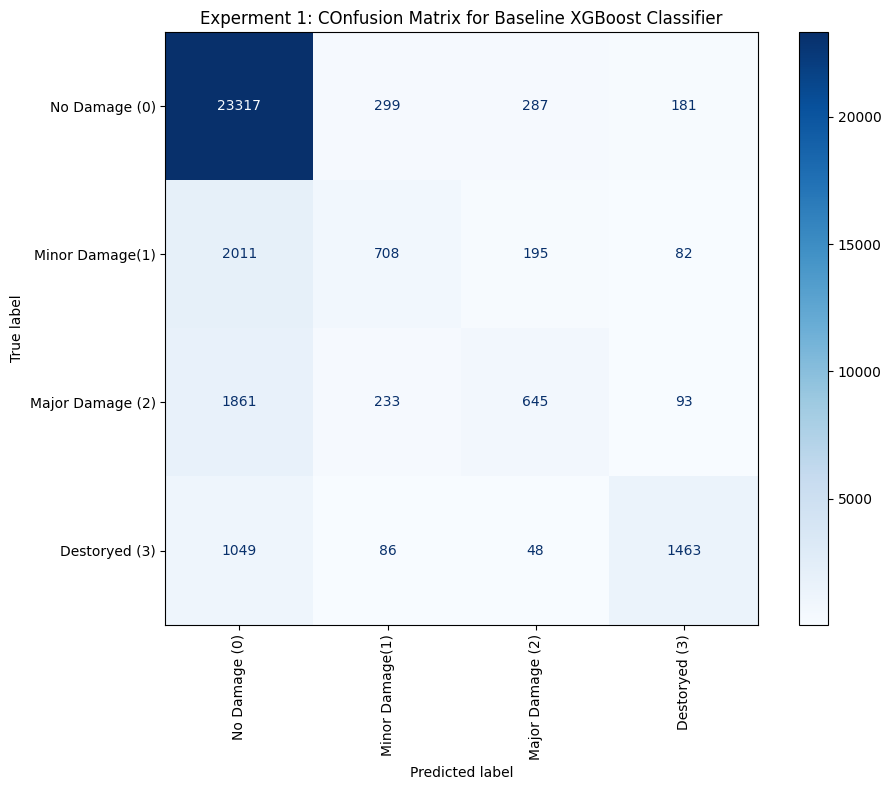

In [17]:
# Plotting Confusion Matrix:
cm= confusion_matrix(y_true= y_test,
                     y_pred= y_pred_classes)

disp= ConfusionMatrixDisplay(confusion_matrix= cm,
                             display_labels= target_names)

fig, ax= plt.subplots(figsize= (10,8))
disp.plot(ax= ax, cmap= 'Blues', xticks_rotation= 'vertical')
plt.title('Experment 1: COnfusion Matrix for Baseline XGBoost Classifier')
plt.tight_layout()
plt.show()

## Experiment 2: Mitigating Class Imbalance by Algorithmic Balancing

### Calculating Sample Weights

In [18]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights= compute_sample_weight(class_weight= 'balanced',
                                      y= y_train)

print(sample_weights)

[0.33795869 0.33795869 0.33795869 ... 0.33795869 2.87379733 3.07695397]


In [19]:
# Checking Class Weight Multiplier for Each Class:
unique_classes, counts = np.unique(y_train, return_counts=True)
unique_weights = np.unique(sample_weights)
print("Class Weight Multipliers:")
for cls, count, weight in zip(unique_classes, counts, unique_weights):
    print(f"Class {cls} ({count} samples): {weight:.4f}x penalty")

Class Weight Multipliers:
Class 0 (96335 samples): 0.3380x penalty
Class 1 (11984 samples): 2.7167x penalty
Class 2 (11329 samples): 2.8738x penalty
Class 3 (10581 samples): 3.0770x penalty


### Training Weighted XGBoost Classifier

In [20]:
# Initializing XGBoost Classifier:
weighted_model= xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    tree_method= 'hist',
    device= 'cuda',
    random_state= 42,
    n_jobs= -1
)

# Model Training:
weighted_model.fit(X_train, y_train, sample_weight= sample_weights)
print('Training Complete.')

Training Complete.


### Evaluating Weighted XGBoost Classifier

In [21]:
# Predictions on Test Set (Probabilities):
y_pred_probs_w= weighted_model.predict_proba(X_test)
y_pred_probs_w

array([[3.9708397e-01, 3.8868412e-01, 1.9074894e-01, 2.3482960e-02],
       [8.4153458e-04, 2.1074398e-04, 2.2858662e-04, 9.9871922e-01],
       [4.8825458e-01, 3.6251122e-01, 5.9785824e-02, 8.9448445e-02],
       ...,
       [8.1740147e-01, 1.6343628e-01, 1.8369490e-02, 7.9275144e-04],
       [6.0984135e-01, 1.6669676e-01, 2.1501698e-01, 8.4449137e-03],
       [8.5065085e-01, 9.3304753e-02, 5.4954413e-02, 1.0900017e-03]],
      shape=(32558, 4), dtype=float32)

In [22]:
# Predictions on Test Set (Classes):
y_pred_classes_w= np.argmax(y_pred_probs_w, axis= 1)
y_pred_classes_w

array([0, 3, 0, ..., 0, 0, 0], shape=(32558,))

In [23]:
# Evaluating The Model:
target_names= ['No Damage (0)',
               'Minor Damage(1)',
               'Major Damage (2)',
               'Destoryed (3)']

print('--- Classification Report for Weighted XGBoost Classifier: ---')
print(classification_report(y_true= y_test,
                            y_pred= y_pred_classes_w,
                            target_names= target_names,
                            zero_division= 0))

--- Classification Report for Weighted XGBoost Classifier: ---
                  precision    recall  f1-score   support

   No Damage (0)       0.91      0.76      0.83     24084
 Minor Damage(1)       0.34      0.52      0.41      2996
Major Damage (2)       0.35      0.52      0.42      2832
   Destoryed (3)       0.52      0.74      0.61      2646

        accuracy                           0.72     32558
       macro avg       0.53      0.64      0.57     32558
    weighted avg       0.78      0.72      0.74     32558



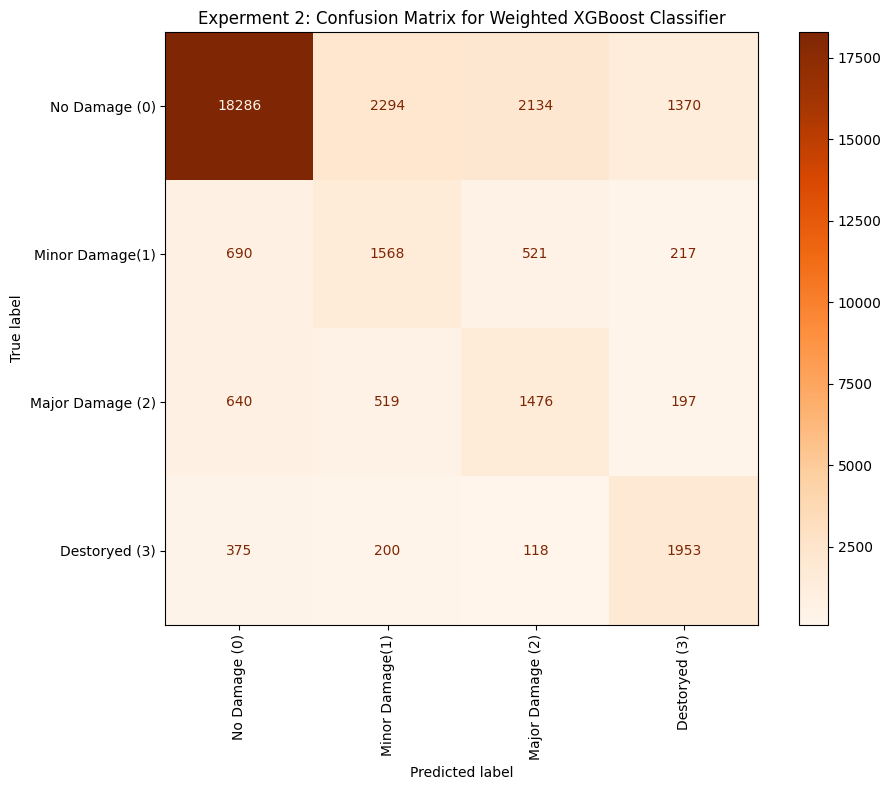

In [24]:
# Plotting Confusion Matrix:
cm= confusion_matrix(y_true= y_test,
                     y_pred= y_pred_classes_w)

disp= ConfusionMatrixDisplay(confusion_matrix= cm,
                             display_labels= target_names)

fig, ax= plt.subplots(figsize= (10,8))
disp.plot(ax= ax, cmap= 'Oranges', xticks_rotation= 'vertical')
plt.title('Experment 2: Confusion Matrix for Weighted XGBoost Classifier')
plt.tight_layout()
plt.show()

## Experiment 3: Mitigating Class Imbalance by Synthetic Balancing (SMOTE)

### Initializing SMOTE

In [25]:
print('Initializing SMOTE... (This might take some time on 2048-d Vectors)')
start_time= time.time()

# SMOTE:
smote= SMOTE(random_state= 42,
             k_neighbors= 5)

# Applying SMOTE on Training Data:
X_train_smote, y_train_smote= smote.fit_resample(X= X_train,
                                                 y= y_train)

end_time= time.time()
print(f'SMOTE Completed in {end_time - start_time:.2f} Seconds.')

Initializing SMOTE... (This might take some time on 2048-d Vectors)
SMOTE Completed in 10.38 Seconds.


### Verifying Class Distrubution in Training Data after applying SMOTE

In [26]:
unique_smote, counts_smote= np.unique(y_train_smote, return_counts= True)
print('New Class Distribution in Training Dataset:')
for u, c in zip(unique_smote, counts_smote):
    print(f'Class {u}: {c} Instances')

New Class Distribution in Training Dataset:
Class 0: 96335 Instances
Class 1: 96335 Instances
Class 2: 96335 Instances
Class 3: 96335 Instances


### Training XGBoost Classifier on Synthetically Balanced Data

In [27]:
# Initializing XGBoost Classifier:
smote_model= xgb.XGBClassifier(
    objective= 'multi:softprob',
    num_class= 4,
    tree_method= 'hist',
    device= 'cuda',
    random_state= 42,
    n_jobs= -1
)

# Model Training:
smote_model.fit(X_train_smote, y_train_smote)
print('Training Complete.')

Training Complete.


### Model Evaluation

In [28]:
# Predictions on Test Set (Probabilities):
y_pred_probs_s= smote_model.predict_proba(X_test)
y_pred_probs_s

array([[3.0071649e-01, 5.1464051e-01, 6.7660280e-02, 1.1698272e-01],
       [4.9053291e-03, 9.5887604e-05, 2.4464238e-04, 9.9475408e-01],
       [9.6528780e-01, 2.0278350e-02, 4.2218869e-03, 1.0211896e-02],
       ...,
       [7.6947463e-01, 1.7321309e-01, 5.4341596e-02, 2.9706827e-03],
       [8.3419067e-01, 1.1098490e-01, 3.6520615e-02, 1.8303826e-02],
       [9.8130774e-01, 7.8216977e-03, 1.0659747e-02, 2.1083727e-04]],
      shape=(32558, 4), dtype=float32)

In [29]:
# Predictions on Test Set (Classes):
y_pred_classes_s= np.argmax(y_pred_probs_s, axis= 1)
y_pred_classes_s

array([1, 3, 0, ..., 0, 0, 0], shape=(32558,))

In [30]:
# Evaluating The Model:
target_names= ['No Damage (0)',
               'Minor Damage(1)',
               'Major Damage (2)',
               'Destoryed (3)']

print('--- Classification Report for XGBoost Classifier (SMOTE): ---')
print(classification_report(y_true= y_test,
                            y_pred= y_pred_classes_s,
                            target_names= target_names,
                            zero_division= 0))

--- Classification Report for XGBoost Classifier (SMOTE): ---
                  precision    recall  f1-score   support

   No Damage (0)       0.83      0.92      0.88     24084
 Minor Damage(1)       0.43      0.27      0.33      2996
Major Damage (2)       0.44      0.27      0.33      2832
   Destoryed (3)       0.69      0.61      0.64      2646

        accuracy                           0.78     32558
       macro avg       0.60      0.52      0.55     32558
    weighted avg       0.75      0.78      0.76     32558



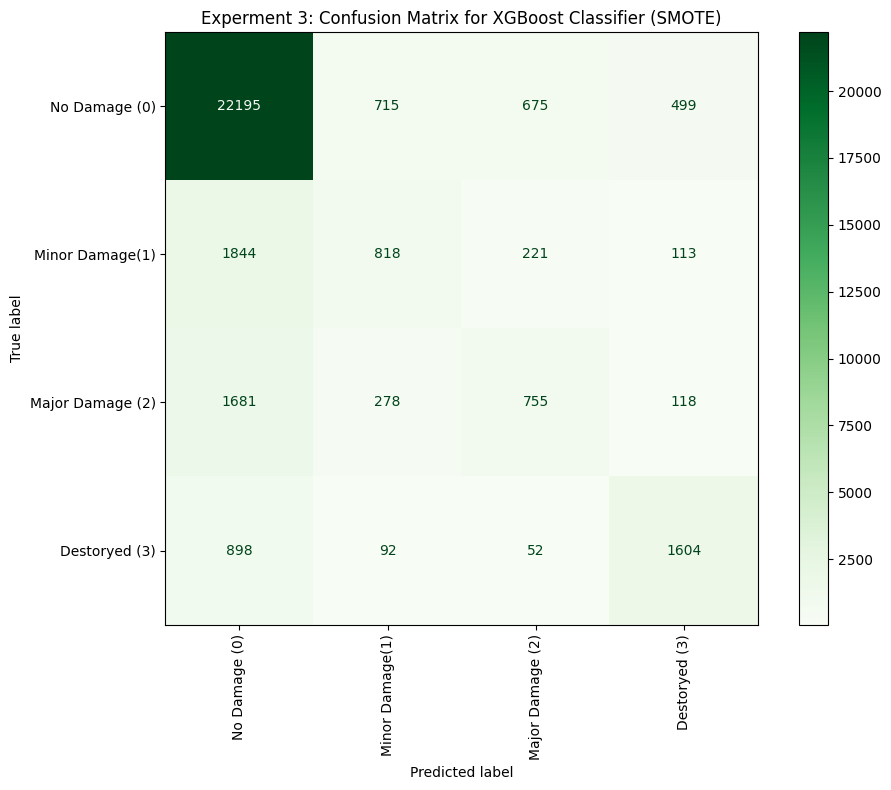

In [31]:
# Plotting Confusion Matrix:
cm= confusion_matrix(y_true= y_test,
                     y_pred= y_pred_classes_s)

disp= ConfusionMatrixDisplay(confusion_matrix= cm,
                             display_labels= target_names)

fig, ax= plt.subplots(figsize= (10,8))
disp.plot(ax= ax, cmap= 'Greens', xticks_rotation= 'vertical')
plt.title('Experment 3: Confusion Matrix for XGBoost Classifier (SMOTE)')
plt.tight_layout()
plt.show()

## Experiment 4: Randomized Search on Algorithmically Balanced Data (Same as Experiment 2)

**Note: For Better GPU Memory Management, using Manual Loop rather than RandomizedSearchCV**

### Parameter Grid

In [32]:
param_grid= {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.7, 0.9],
    'gamma': [0, 1, 3]
}

### Train Test Split

In [33]:
X_tune_train, X_tune_val, y_tune_train, y_tune_val= train_test_split(
    X_train,
    y_train,
    test_size= 0.2,
    random_state= 42,
    stratify= y_train
)

### Calculating Sample Weights for Specific Tuning Dataset

In [34]:
tune_sample_weights= compute_sample_weight(class_weight= 'balanced',
                                           y= y_tune_train)

### Randomized Serach Training Loop (Manual)

In [37]:
best_score= 0
best_params= {}
ITERATIONS= 50

print(f'Starting {ITERATIONS} Manual fits for Random Search...')
start_time= time.time()

# Training Loop:
for i in range(ITERATIONS):

    # Randomly Sampling Parameters:
    params= {k: random.choice(v) for k, v in param_grid.items()}

    # Initializing Model:
    model= xgb.XGBClassifier(
        **params,
        objective= 'multi:softprob',
        num_class= 4,
        tree_method= 'hist',
        device= 'cuda',
        random_state= 42
    )
    # Measuring Time for Iteration:
    iter_start_time= time.time()

    # Fitting the model
    model.fit(X_tune_train, y_tune_train, sample_weight= tune_sample_weights, verbose= False)

    iter_end_time= time.time()

    # Evaluzting the Model:
    preds= model.predict(X_tune_val)
    score= f1_score(y_true= y_tune_val, y_pred= preds, average= 'macro')

    # Progress:
    print(f'Iter {i+1}/{ITERATIONS} | Time: {(iter_end_time - iter_start_time) / 60:.2f} Mins | F1: {score:.4f} | Params: {params}')

    # Saving the Best Score and Params:
    if score > best_score:
        best_score= score
        best_params= params
    
    # Memory Management by Manually Deleting the Model from VRAM:
    del model
    del preds
    gc.collect()

end_time= time.time()

print(f"\nCustom Randomized Search Loop Complete in {(end_time - start_time) / 60:.2f} Minutes.")
print(f"Best Score: {best_score:.4f}")
print(f"Best Hyperparameters:\n{best_params}")


Starting 50 Manual fits for Random Search...
Iter 1/50 | Time: 0.20 Mins | F1: 0.5222 | Params: {'n_estimators': 200, 'learning_rate': 0.2, 'max_depth': 3, 'subsample': 1.0, 'colsample_bytree': 0.9, 'gamma': 1}
Iter 2/50 | Time: 0.44 Mins | F1: 0.5540 | Params: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 7, 'subsample': 1.0, 'colsample_bytree': 0.9, 'gamma': 0}
Iter 3/50 | Time: 0.37 Mins | F1: 0.5446 | Params: {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 1.0, 'colsample_bytree': 0.9, 'gamma': 3}
Iter 4/50 | Time: 0.82 Mins | F1: 0.5844 | Params: {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 7, 'subsample': 1.0, 'colsample_bytree': 0.9, 'gamma': 1}
Iter 5/50 | Time: 1.22 Mins | F1: 0.5953 | Params: {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 7, 'subsample': 1.0, 'colsample_bytree': 0.9, 'gamma': 0}
Iter 6/50 | Time: 0.14 Mins | F1: 0.4751 | Params: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1

### Training the Model using Best Params found on Full Data

In [38]:
# InitializignXGBoost Classifier with Best Parameters
best_model= xgb.XGBClassifier(
    **best_params,
    objective= 'multi:softprob',
    num_class= 4,
    tree_method= 'hist',
    device= 'cuda',
    random_state= 42
)

# Training:
best_model.fit(X_train, y_train, sample_weight= sample_weights)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 